<a href="https://colab.research.google.com/github/rxphaelbihag/Synthetic-Data-Generation/blob/main/Synthetic_Data_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Urban Air Quality EDA

## Introduction
This notebook serves as the Exploratory Data Analysis of synthetic data generated using TimeGAN introduced by Jinsung Yoon, Daniel Jarrett, and Mihaela van der Schaar in 2019. View their GitHub repository [here](https://github.com/jsyoon0823/timegan).


The original dataset was derived from Project CCHAIN in [Kaggle](https://www.kaggle.com/datasets/thinkdatasci/project-cchain).

**"**
> The Project Climate Change, Health, and Artificial Intelligence (Project CCHAIN) dataset is a validated, open-sourced linked dataset containing 20 years (2003-2022) of climate, environmental, socioeconomic, and health dimensions at the barangay (village) level across twelve Philippine cities (Dagupan, Palayan, Navotas, Mandaluyong, Muntinlupa, Legazpi, Iloilo, Mandaue, Tacloban, Zamboanga, Cagayan de Oro, Davao).

**"**
---

**Target location:** Brgy. Agdao, Davao City.

**Focused Datasets:**
- climate_air_quality.csv (For Air Pollutants)
- climate_atmosphere.csv (For Weather Proxies)


The timeframe for this project spans from **2018 to 2022** (latest available).

The `pollutants_info.csv` is a directory containing the relevant information of the pollutants such as their full names, health effects, and regulatory limits.

---
**Pre Processing and TimeGAN Implementation**


The datasets used in this project were already preprocessed in a separate notebook. View the predecessor notebooks here:
- [Data_Loading.ipynb](https://github.com/rxphaelbihag/Synthetic-Data-Generation/blob/main/Data_Loading.ipynb)
- [TimeGAN Implementation (Weather)](https://github.com/rxphaelbihag/Synthetic-Data-Generation/blob/main/runs/2018_2022/TimeGAN-Tensor-py3_7-weather_2018.ipynb)
- [TimeGAN Implementation (Pollutants)](https://github.com/rxphaelbihag/Synthetic-Data-Generation/blob/main/runs/2018_2022/TimeGAN-Tensor-py3_7-pollutants_2018.ipynb)

---

**Data Dictionary**


Weather Variables
| name | type | Default Value & Notes  |
| -------- | -------- | -------- |
| `tave`   | float     | Average temperature (°C) of air at 2m above the surface of land, sea, or inland waters. Extracted from ERA5.|
| `pr`    | float     | Rainfall estimates (mm/day) from rain gauge and satellite observations.|
| `wind_speed`    | float     | 10m wind speed (m/s) derived from eastward and northward wind components. Extracted from ERA5.|
| `rh`    | float     | Water vapor pressure (%) at which the air becomes saturated (i.e., water vapor begins to condense into liquid water). Extracted from ERA5.|
| `solar_rad`    | float     | Solar radiation (J/m²) that reaches a horizontal plane at the surface of the earth. This comprises both direct and diffuse solar radiation. Extracted from ERA5.|


Pollutants
| name | type | Default Value & Notes  |
| -------- | -------- | -------- |
| `no2`   | float     | Concentration of nitrogen dioxide (ppb) at model level 60. Extracted from CAMS.|
| `co`   | float     | Surface concentration of carbon monoxide (ppm). Extracted from MERRA-2. |
| `so2`   | float     | Surface mass concentration of sulfur dioxide (ppm). Extracted from MERRA-2. |
| `o3`   | float     | Ozone mixing ratio (ppb) or mass of ozone per kilogram of air at 1,000 hPa. Extracted from ERA5. |
| `pm10`   | float     | Concentration of particulate matter with a diameter less than 10 μm (kg/m³). Extracted from CAMS.|
| `pm25`   | float     | Concentration of particulare matter with a diameter less than 2.5 μm (kg/m³). Extracted from CAMS. |

Note: We have log-transformed the `pr` or the precipitation column of the weather variables dataset.

## Load Necessary Libraries

In [1]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="darkgrid")


import warnings
warnings.filterwarnings("ignore")
print("Successfully loaded necessary libraries!")

Successfully loaded necessary libraries!


## Load the datasets

In [2]:
# @title

# Data from github
weather_url = "https://raw.githubusercontent.com/rxphaelbihag/Synthetic-Data-Generation/refs/heads/main/data/2018_2022/brgy_agdao_weather_2018.csv"
pollutants_url = "https://raw.githubusercontent.com/rxphaelbihag/Synthetic-Data-Generation/refs/heads/main/data/2018_2022/brgy_agdao_pollutants_2018.csv"
synth_weather_url = "https://raw.githubusercontent.com/rxphaelbihag/Synthetic-Data-Generation/refs/heads/main/data/2018_2022/synthetic_brgy_agdao_weather_2018.csv"
synth_pollutants_url = "https://raw.githubusercontent.com/rxphaelbihag/Synthetic-Data-Generation/refs/heads/main/data/2018_2022/synthetic_brgy_agdao_pollutants_2018.csv"
pollutants_info = "https://raw.githubusercontent.com/rxphaelbihag/Synthetic-Data-Generation/refs/heads/main/data/pollutants_info.csv"


# Loading the real datasets to pandas dataframes
agdao_clim_atmo_df = pd.read_csv(weather_url)
agdao_clim_airqual_df = pd.read_csv(pollutants_url)

# Loading the synthetic datasets to pandas dataframes
synth_clim_atmo_df = pd.read_csv(synth_weather_url)
synth_clim_airqual_df = pd.read_csv(synth_pollutants_url)

# Loading the pollutants info directory
pollutants_df = pd.read_csv(pollutants_info).iloc[:6]

# Setting date columns as indexes
synth_clim_atmo_df['date'] = pd.to_datetime(synth_clim_atmo_df['date'])
synth_clim_atmo_df.set_index('date', inplace=True)
synth_clim_airqual_df['date'] = pd.to_datetime(synth_clim_airqual_df['date'])
synth_clim_airqual_df.set_index('date', inplace=True)

# Reversed the Log Transform on the Precipitation variable
synth_clim_atmo_df['pr'] = np.exp(synth_clim_atmo_df['pr'])

print("All datasets are loaded!")

All datasets are loaded!


Since the dataset processing removed the date column for TimeGAN implementation, we will be adding it back here for visualization purposes.

In [3]:
# @title

# -- Adding date to real data --
agdao_clim_atmo_df.insert(0, 'date', pd.date_range(start='2018-01-01', periods=len(agdao_clim_atmo_df), freq='D'))
agdao_clim_airqual_df.insert(0, 'date', pd.date_range(start='2018-01-01', periods=len(agdao_clim_airqual_df), freq='D'))
agdao_clim_atmo_df = agdao_clim_atmo_df.set_index('date')
agdao_clim_airqual_df = agdao_clim_airqual_df.set_index('date')
print("Fixed Date Column on Real Data!")

Fixed Date Column on Real Data!


Let's look at our datasets!

In [4]:
# @title
datasets_info = {
    'Weather Data': agdao_clim_atmo_df.shape,
    'Pollutants Data': agdao_clim_airqual_df.shape,
    'SYNTHETHIC Weather Data': synth_clim_atmo_df.shape,
    'SYNTHETHIC Pollutants Data': synth_clim_airqual_df.shape,
    'Pollutants Information': pollutants_df.shape
}

print("Dataset dimensions (rows × columns):")
print("-" * 40)
for name, shape in datasets_info.items():
    print(f"{name:<30}: {shape[0]:,} × {shape[1]}")

Dataset dimensions (rows × columns):
----------------------------------------
Weather Data                  : 1,826 × 5
Pollutants Data               : 1,826 × 6
SYNTHETHIC Weather Data       : 1,825 × 5
SYNTHETHIC Pollutants Data    : 1,825 × 6
Pollutants Information        : 6 × 4


In [5]:
# @title
pollutants_df

,pollutant_id,full_name,regulatory_limit,health_effect
0,pm2_5,Particulate Matter (Fine Particles),50.0,"lung inflammation, systemic inflammatory changes"
1,pm10,Particulate Matter (Inhalable Coarse Particles),150.0,"lung inflammation, inflammatory changes"
2,no2,Nitrogen Dioxide,150.0,"Nose and throat irritation, bronchoconstrictio..."
3,o3,Ozone,140.0,"lung inflammation, reduce lung function, incre..."
4,so2,Sulfur Dioxide,180.0,"Nose and throat irritation, bronchoconstrictio..."
5,co,Carbon Monoxide,35.0,reduced blood oxygen transfer resulting in imp...


## Real vs Synthetic Data Visualization

Let us take a look on how the two types of datasets are different through their KDE plots. As we can see from the visualization below, there seems to be no significant different in the distributions between the datasets. The TimeGAN was able to capture hte distribution of each variables.

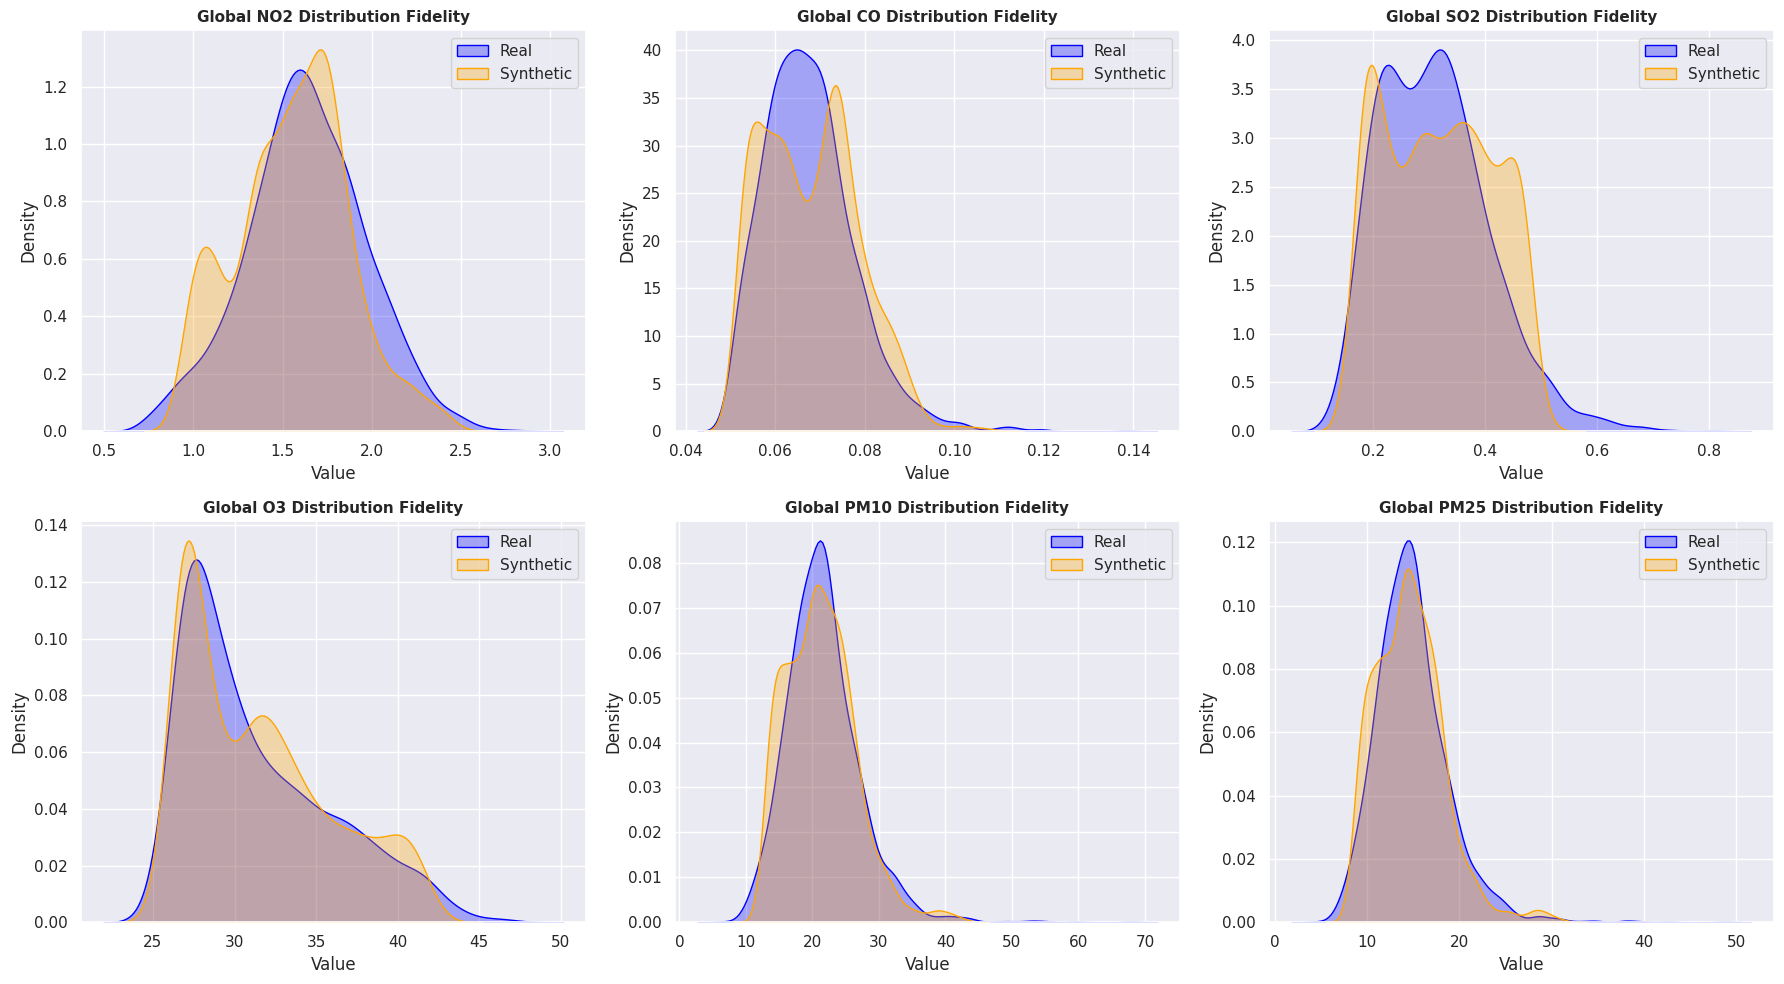

In [6]:
# @title
columns_to_plot = agdao_clim_airqual_df.columns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):

    sns.kdeplot(data=agdao_clim_airqual_df[col], label='Real', ax=axes[i], fill=True, alpha=0.3, color='blue')
    sns.kdeplot(data=synth_clim_airqual_df[col], label='Synthetic', ax=axes[i], fill=True, alpha=0.3, color='orange')

    axes[i].set_title(f"Global {col.upper()} Distribution Fidelity", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

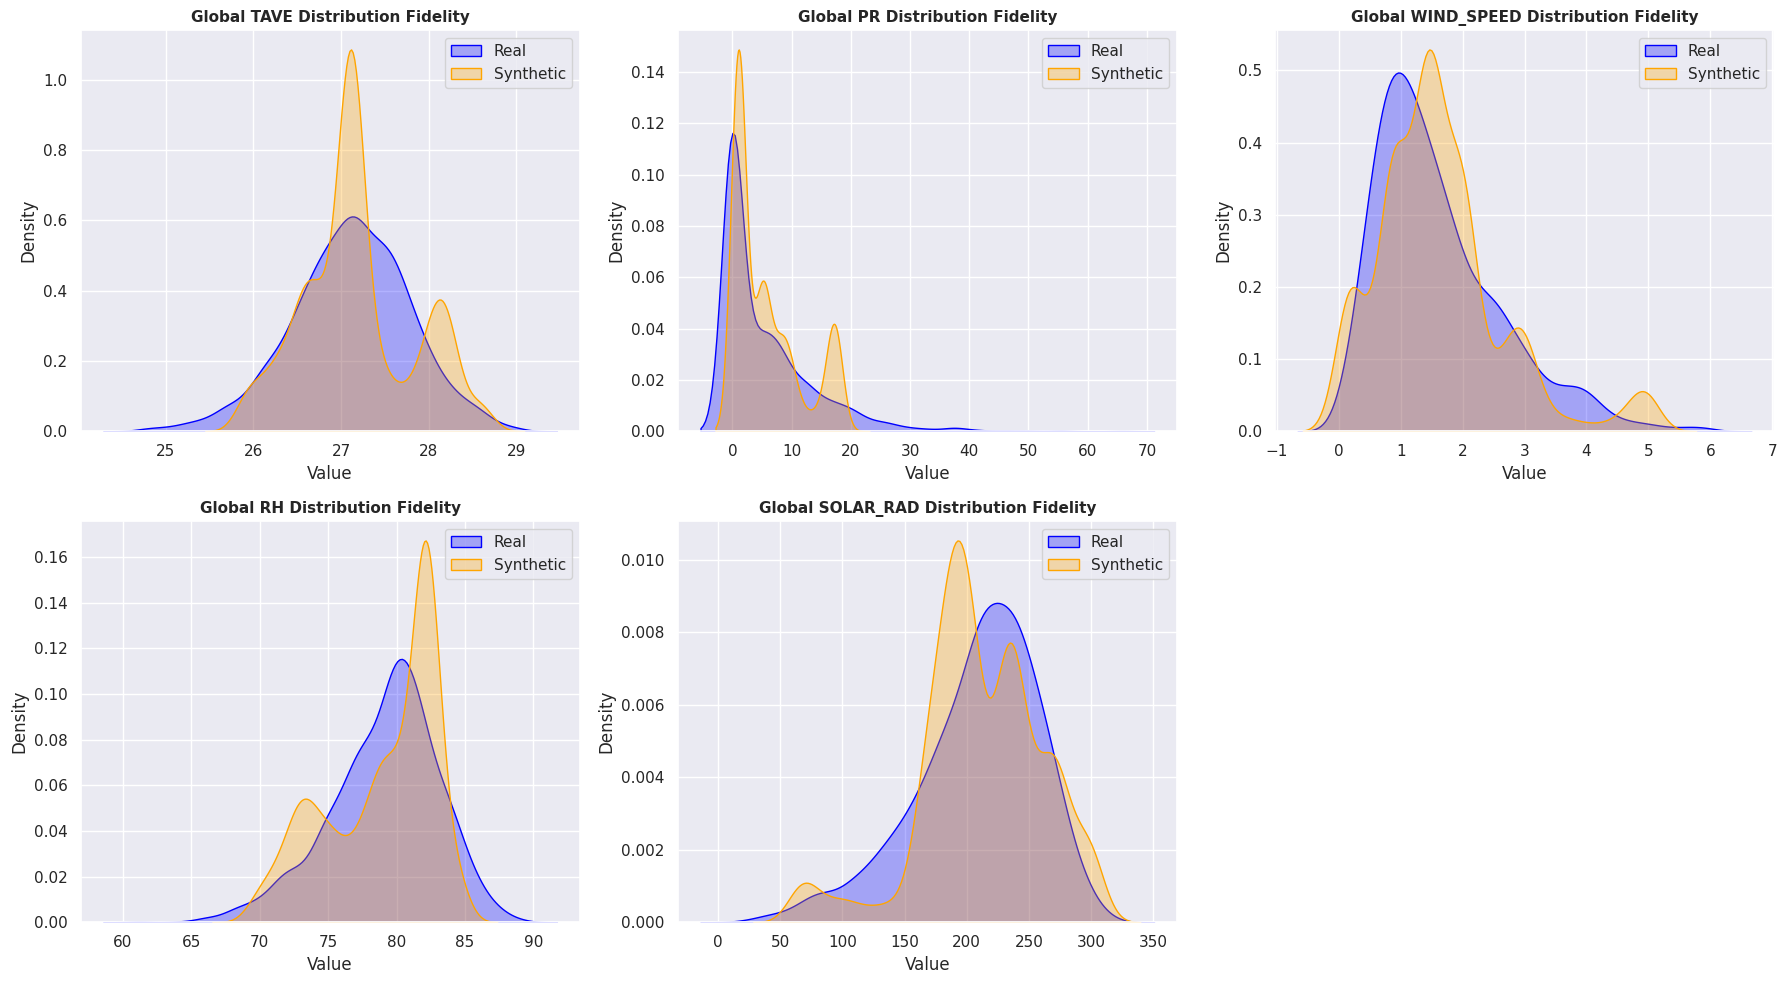

In [7]:
# @title
columns_to_plot = agdao_clim_atmo_df.columns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):

    sns.kdeplot(data=agdao_clim_atmo_df[col], label='Real', ax=axes[i], fill=True, alpha=0.3, color='blue')
    sns.kdeplot(data=synth_clim_atmo_df[col], label='Synthetic', ax=axes[i], fill=True, alpha=0.3, color='orange')

    axes[i].set_title(f"Global {col.upper()} Distribution Fidelity", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Synthetic Pollution Data Exploratory Analysis

### Pollution Levels

Let's look at an overview of the Pollution Levels in Barangay Agdao in the latest 5 years (2018-2022). To do this, let us plot the box plots of each as well as their summary statistics.

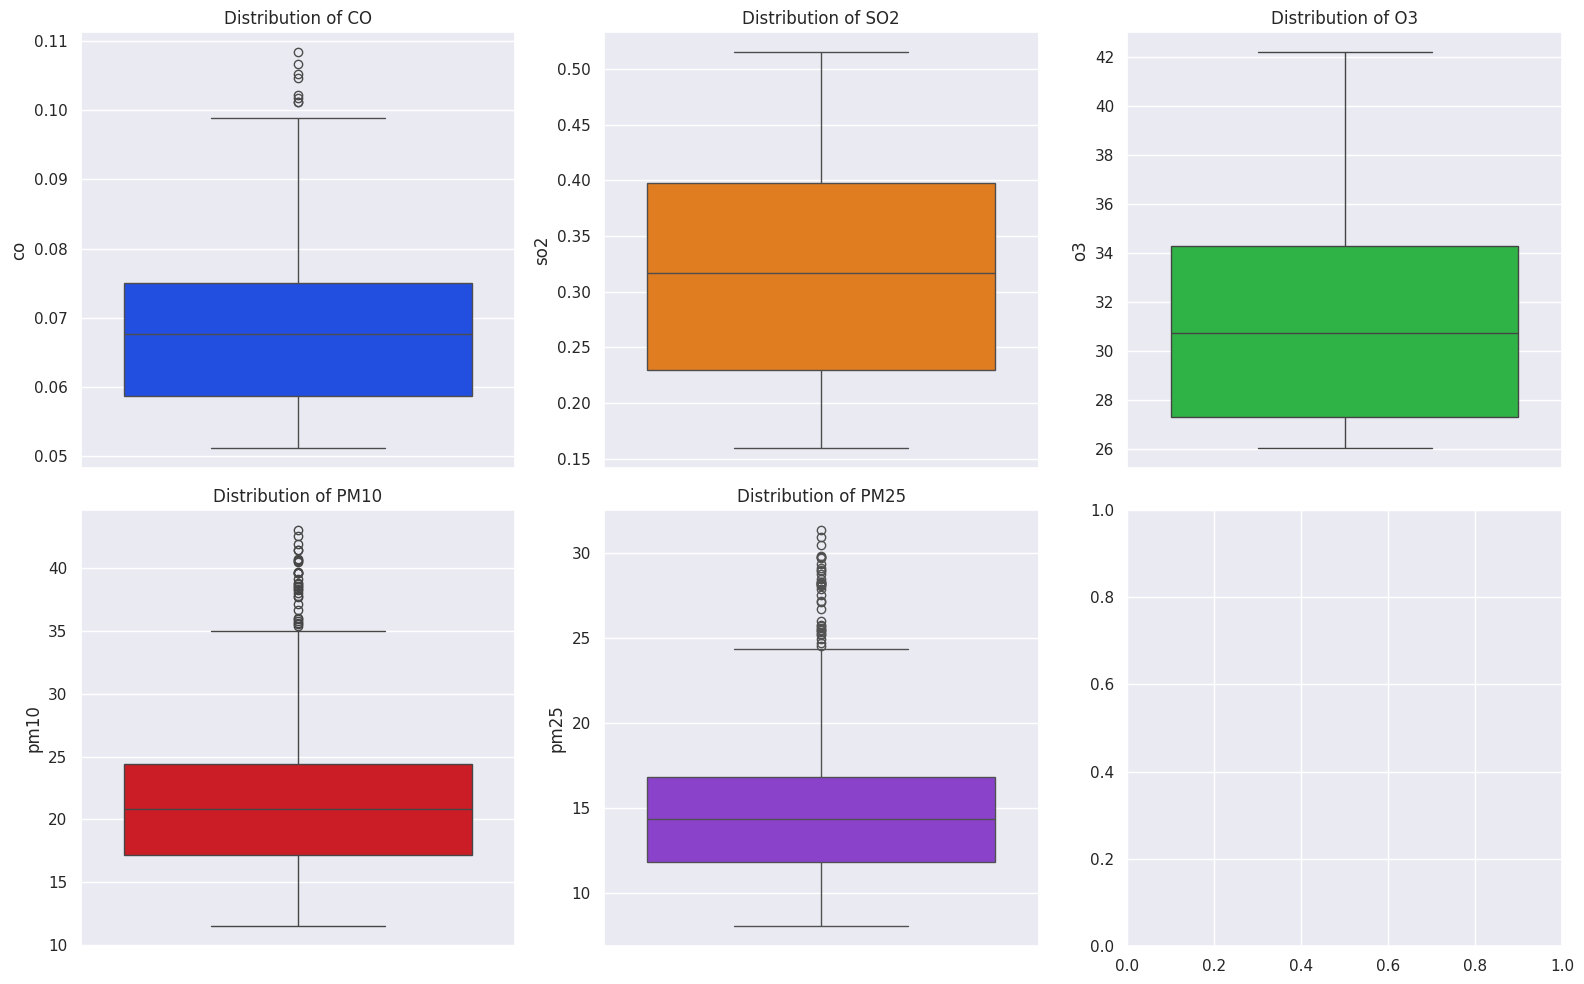

In [8]:
# @title
synth_clim_airqual_df_5 = synth_clim_airqual_df[
    synth_clim_airqual_df.index > "2018-01-01" ]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

unique_colors = sns.color_palette("bright", n_colors=6)

for i, col in enumerate(synth_clim_airqual_df_5.iloc[:, 1:].columns):
    sns.boxplot(
        data=synth_clim_airqual_df_5.iloc[:, 1:], y=col, ax=axes.flatten()[i], color=unique_colors[i]
    )
    axes.flatten()[i].set_title(f"Distribution of {col.upper()}")

plt.tight_layout()
plt.show()

In [9]:
# @title
print(" === Summary Statistics of Pollutants ===\n")
synth_clim_airqual_df_5.iloc[:, 1:].describe()

 === Summary Statistics of Pollutants ===



,co,so2,o3,pm10,pm25
count,1824.000000,1824.000000,1824.000000,1824.000000,1824.000000
mean,0.067912,0.317986,31.450693,21.198257,14.616297
std,0.010622,0.095165,4.443952,5.255112,3.752899
min,0.051136,0.159622,26.046208,11.505723,8.067634
25%,0.058665,0.229868,27.330374,17.126455,11.813306
50%,0.067657,0.316702,30.764472,20.821408,14.337321
75%,0.074999,0.397641,34.300856,24.408211,16.855571
max,0.108390,0.514944,42.203889,43.064833,31.373624


### Seasonal Trends
Let us look at how pollutants vary across months. Here, we can see if certain pollutants are prevalent during the different seasons in the Philippines.

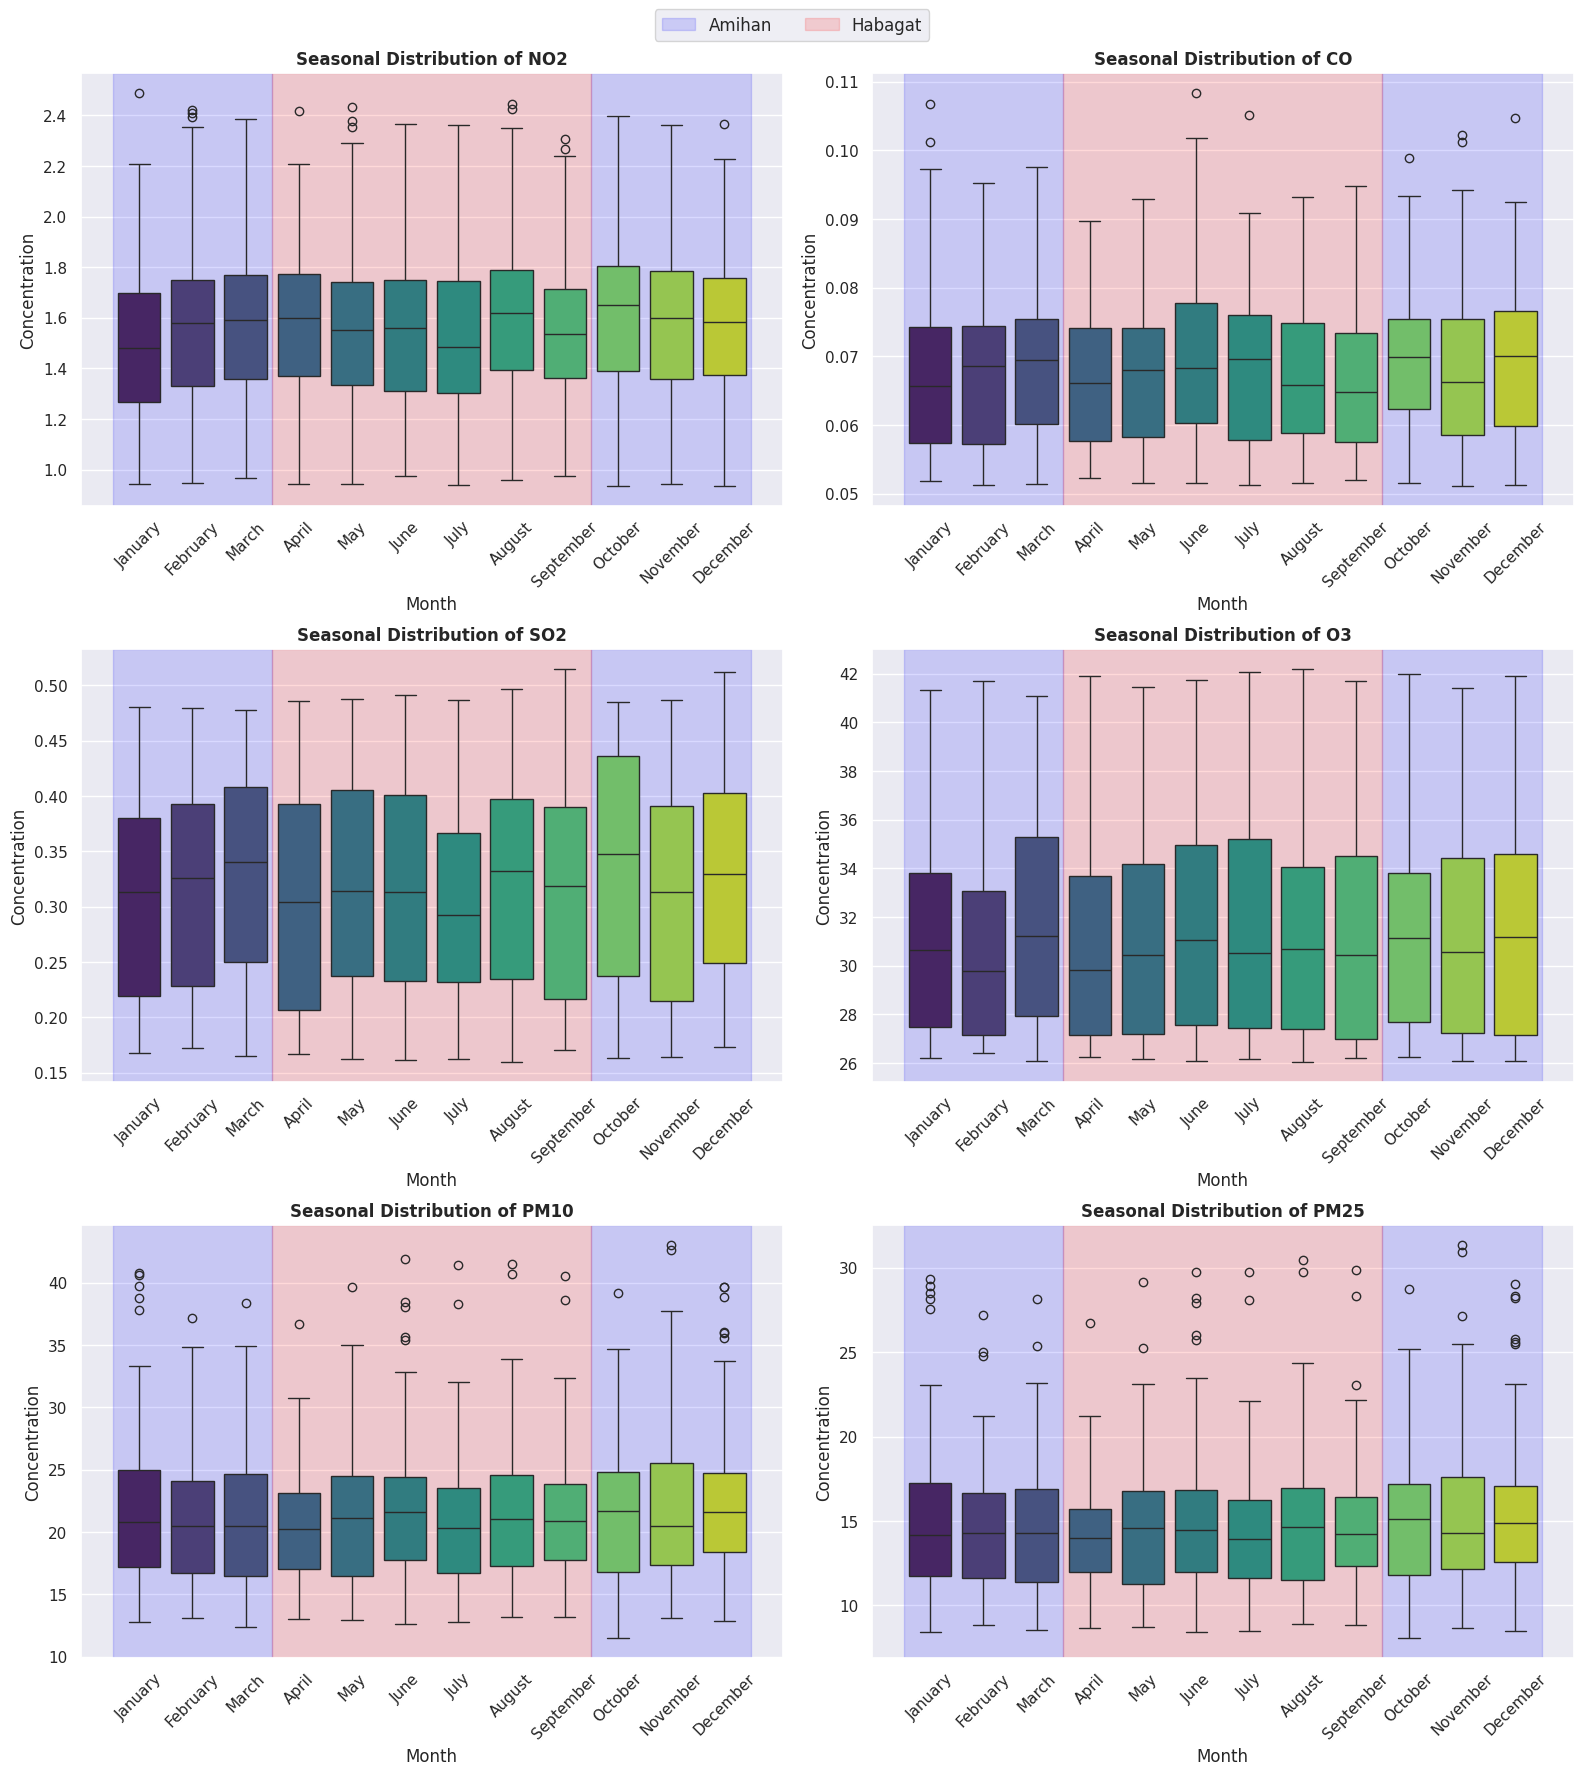

In [10]:
# @title
WEATHER_COLUMNS = ['no2', 'co', 'so2', 'o3', 'pm10', 'pm25']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

synth_clim_airqual_df['Month_Name'] = synth_clim_airqual_df.index.strftime('%B')

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, var in enumerate(WEATHER_COLUMNS):
    sns.boxplot(
        data=synth_clim_airqual_df,
        x='Month_Name',
        y=var,
        order=month_order,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(f'Seasonal Distribution of {var.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Concentration')
    axes[i].tick_params(axis='x', rotation=45)

   # --- Amihan and Habatag highlights ---
    label_a = 'Amihan' if i == 0 else "_nolegend_"
    label_h = 'Habagat' if i == 0 else "_nolegend_"

    axes[i].axvspan(-0.5, 2.5, color='blue', alpha=0.15, label=label_a)
    axes[i].axvspan(8.5, 11.5, color='blue', alpha=0.15)
    axes[i].axvspan(2.5, 8.5, color='red', alpha=0.15, label=label_h)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=2, fontsize=12)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Yearly Trends
Here we can see if the pollution levels have been increasing over the years.

Successfully resampled weather variables to Yearly Averages!


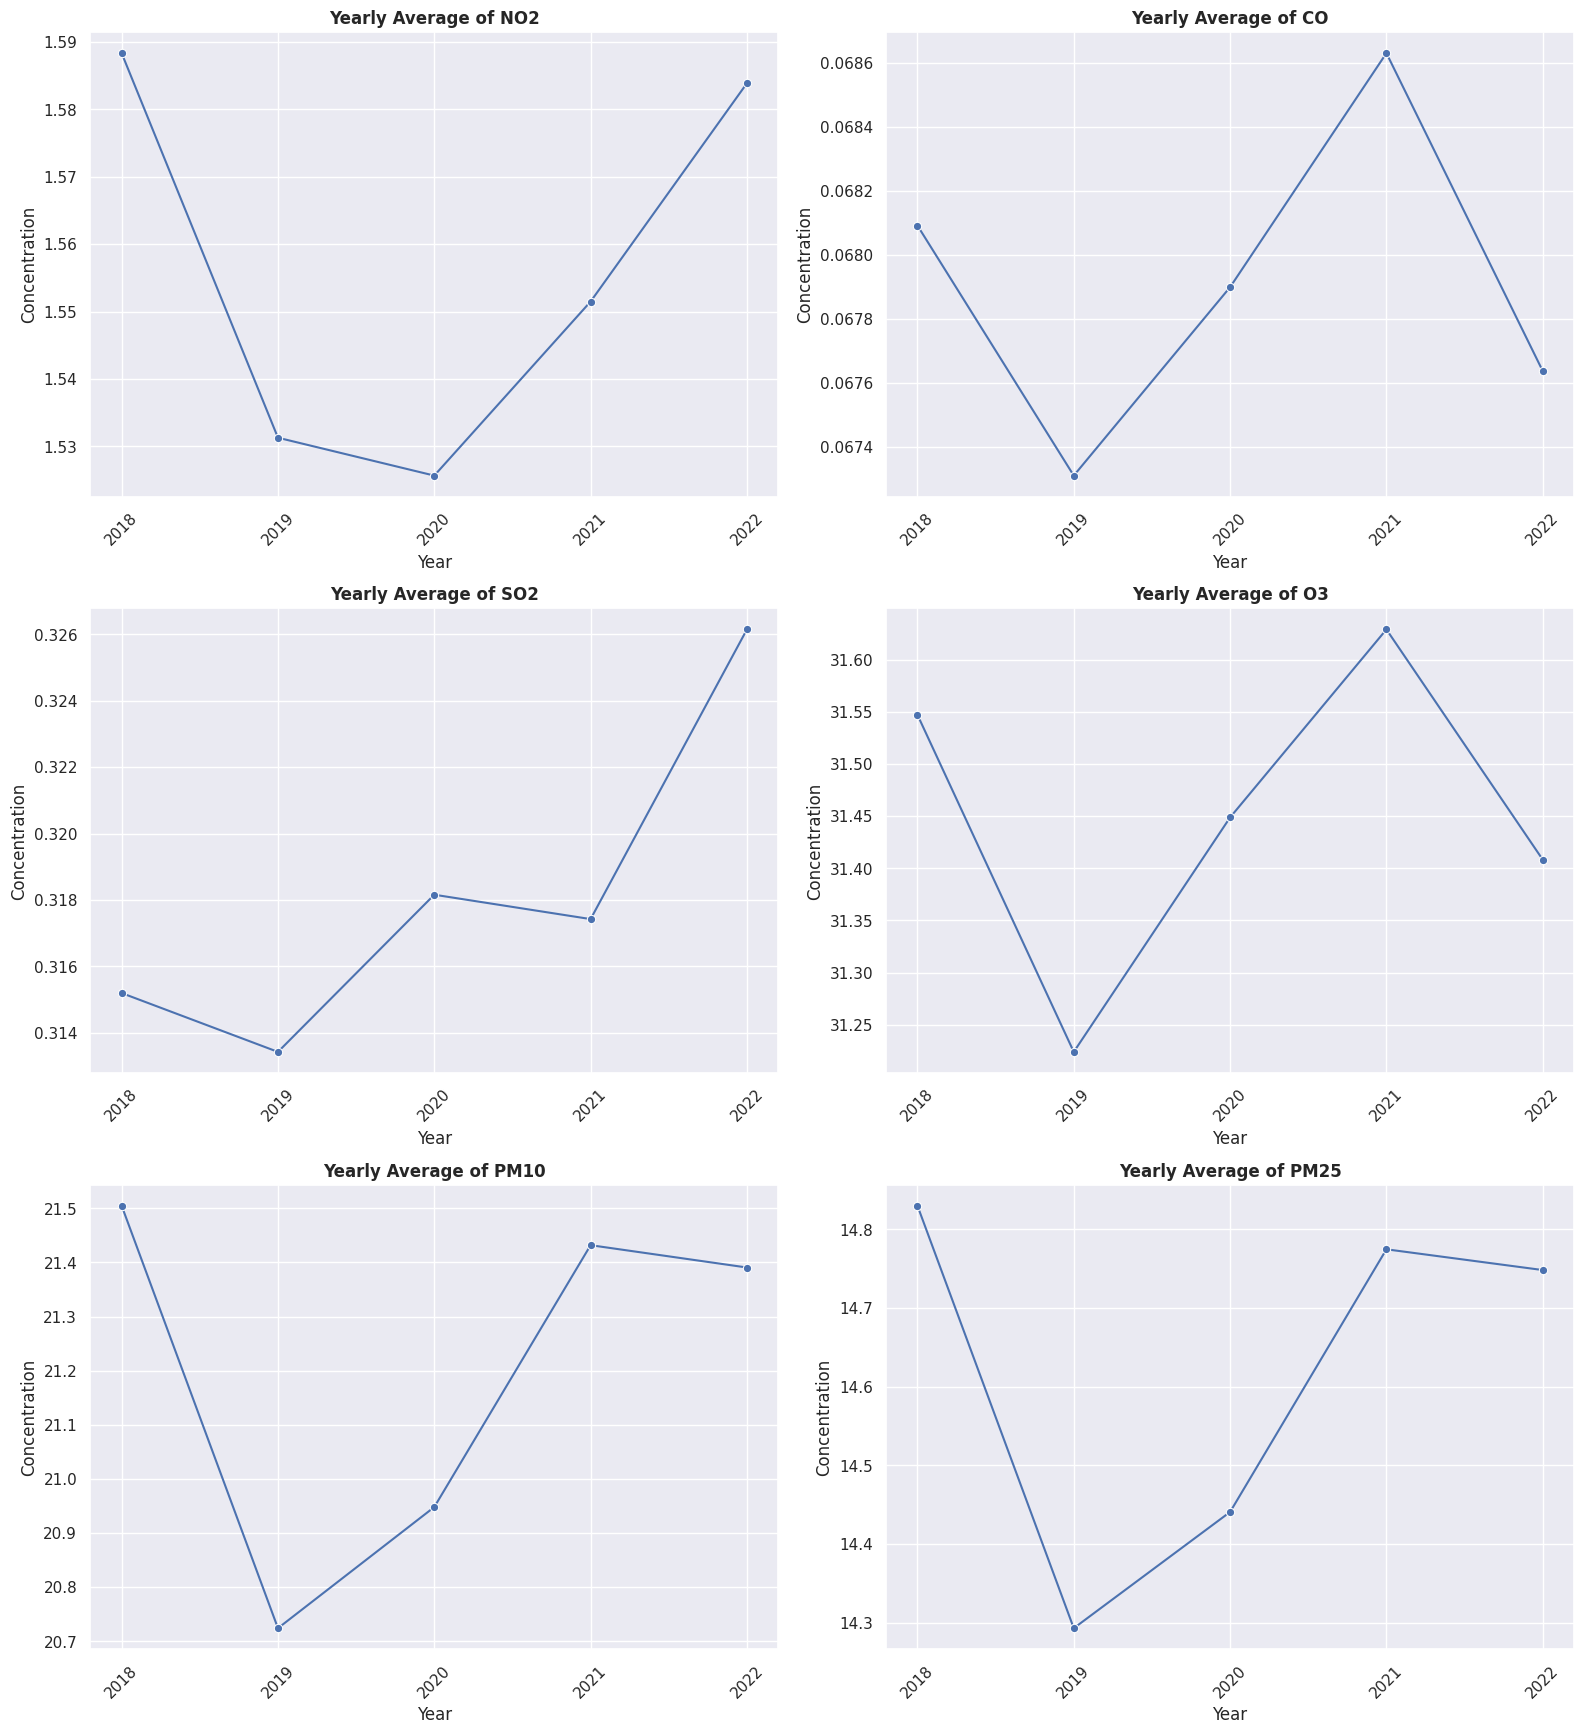

In [11]:
# @title
WEATHER_COLUMNS = ['no2', 'co', 'so2', 'o3', 'pm10', 'pm25']
yearly_airqual = synth_clim_airqual_df.iloc[:, :6].resample('Y').mean()
print("Successfully resampled weather variables to Yearly Averages!")
yearly_airqual['Year'] = yearly_airqual.index.year

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, var in enumerate(WEATHER_COLUMNS):
    sns.lineplot(data=yearly_airqual, x='Year', y=var, marker='o', ax=axes[i])

    axes[i].set_title(f'Yearly Average of {var.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Concentration')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticks(yearly_airqual['Year'].unique())

plt.tight_layout()
plt.subplots_adjust(top=0.95)

### Pollution Status
The [Air Quality Index Hub](https://aqihub.info/indices/philippines) outlines the different breakpoints for each pollutants to classify their status from Good to Emergency. After mapping out the status of each pollutant every day, we look at the proportional status distribution to see which pollutant has been at healthy levels.

In [12]:
# @title
# Define the standard text labels
labels_standard = [
    "Good",
    "Fair",
    "Unhealthy for sensitive groups",
    "Very unhealthy",
    "Acutely unhealthy",
    "Emergency",
]

# --- PM10 Status ---
synth_clim_airqual_df["pm10_status"] = pd.cut(
    synth_clim_airqual_df["pm10"],
    bins=[-1, 54, 154, 254, 354, 424, float("inf")],
    labels=labels_standard,
)

# --- PM2.5 Status ---
synth_clim_airqual_df["pm25_status"] = pd.cut(
    synth_clim_airqual_df["pm25"],
    bins=[-1, 25, 35, 45, 55, 90, float("inf")],
    labels=labels_standard,
)

# --- SO2 Status ---
synth_clim_airqual_df["so2_status"] = pd.cut(
    synth_clim_airqual_df["so2"],
    bins=[-1, 0.034, 0.144, 0.224, 0.304, 0.604, float("inf")],
    labels=labels_standard,
)

# --- CO Status ---
synth_clim_airqual_df["co_status"] = pd.cut(
    synth_clim_airqual_df["co"],
    bins=[-1, 4.4, 9.4, 12.4, 15.4, 30.4, float("inf")],
    labels=labels_standard,
)

# --- O3 Status (8-hr standard) ---
# Note: 8-hr O3 in the table does not define an Emergency level (-)
synth_clim_airqual_df["o3_status"] = pd.cut(
    synth_clim_airqual_df["o3"],
    bins=[-1, 0.064, 0.084, 0.104, 0.124, 0.374, float("inf")],
    labels=[
        "Good",
        "Fair",
        "Unhealthy for sensitive groups",
        "Very unhealthy",
        "Acutely unhealthy",
        "Undefined/Emergency",
    ],
)

# --- NO2 Status (1-hr standard) ---
# Note: NO2 values below 0.65 are not explicitly categorized (-) in the table
synth_clim_airqual_df["no2_status"] = pd.cut(
    synth_clim_airqual_df["no2"],
    bins=[-1, 0.64, 1.24, float("inf")],
    labels=["Not Specified", "Acutely unhealthy", "Emergency"],
)

print("Air Quality Breakpoints successfully added!")

Air Quality Breakpoints successfully added!


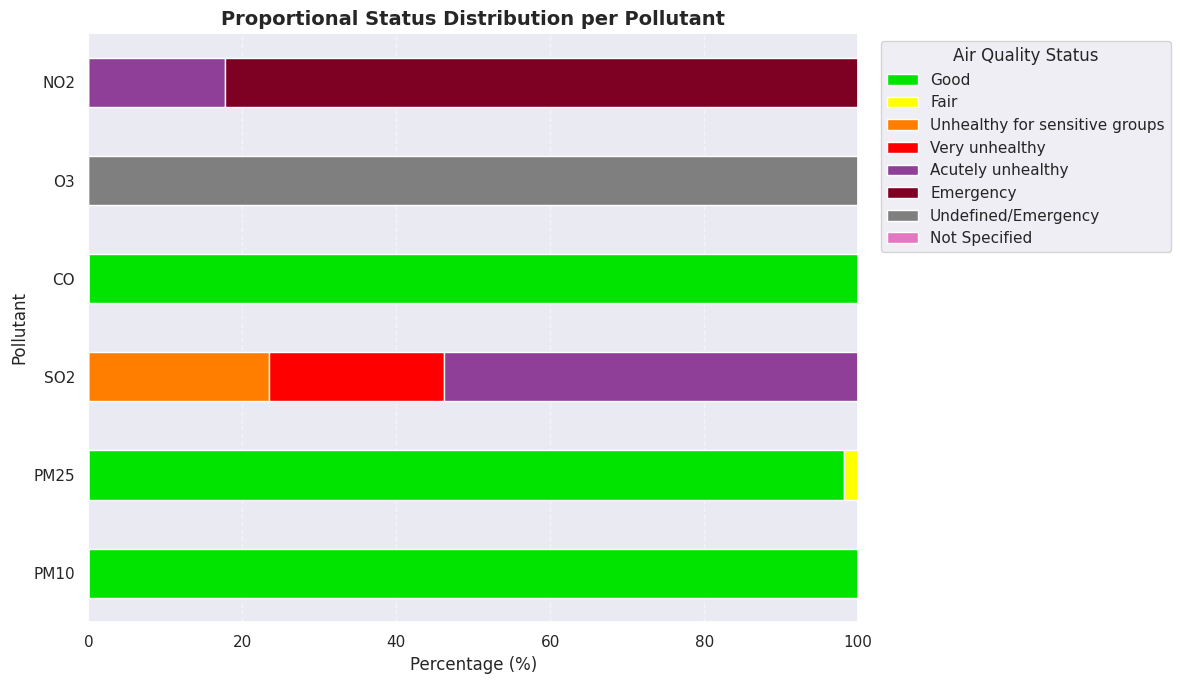

In [13]:
# @title
# List of the status columns to plot
status_cols = [
    "pm10_status",
    "pm25_status",
    "so2_status",
    "co_status",
    "o3_status",
    "no2_status",
]

# 1. Calculate the percentage distribution for each pollutant status
distribution_data = {}
for col in status_cols:
    # Get raw counts including any unassigned/not-specified statuses
    counts = synth_clim_airqual_df[col].value_counts()
    # Convert counts to percentages (0 to 100)
    percentages = (counts / counts.sum()) * 100
    # Clean the column name for the plot label (e.g., 'pm10_status' -> 'PM10')
    clean_name = col.replace("_status", "").upper()
    distribution_data[clean_name] = percentages

# Combine into a single DataFrame and fill missing statuses with 0
plot_df = pd.DataFrame(distribution_data).T

# 2. Define the exact color mapping (Good = Green -> Emergency = Red)
# This includes all specific labels used across the different columns
color_map = {
    "Good": "#00e400",  # Green
    "Fair": "#ffff00",  # Yellow-Green
    "Unhealthy for sensitive groups": "#ff7e00",  # Orange
    "Very unhealthy": "#ff0000",  # Light Red
    "Acutely unhealthy": "#8f3f97",  # Purple / Deep Crimson
    "Emergency": "#7e0023",  # Dark Maroon / Grey-Red boundary
    "Undefined/Emergency": "#7f7f7f",
    "Not Specified": "#e377c2",  # Muted color for unclassified low values
}

# Ensure the columns follow a logical progression from Good to Emergency
# (Reorders the legend segments nicely)
desired_order = [
    "Good",
    "Fair",
    "Unhealthy for sensitive groups",
    "Very unhealthy",
    "Acutely unhealthy",
    "Emergency",
    "Undefined/Emergency",
    "Not Specified",
]
available_columns = [col for col in desired_order if col in plot_df.columns]
plot_df = plot_df[available_columns]

# 3. Create the 100% Stacked Horizontal Bar Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Get colors in the correct order mapped to the DataFrame columns
colors = [color_map[col] for col in plot_df.columns]

# Plot stacked bars
plot_df.plot(kind="barh", stacked=True, color=colors, ax=ax)

# Formatting the visual representation
ax.set_title(
    "Proportional Status Distribution per Pollutant",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Percentage (%)", fontsize=12)
ax.set_ylabel("Pollutant", fontsize=12)
ax.set_xlim(0, 100)

# Move the legend outside the plot box so it doesn't block data bars
ax.legend(
    title="Air Quality Status", bbox_to_anchor=(1.02, 1), loc="upper left"
)

# Add light vertical gridlines at 10% increments for easier parsing
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Synthetic Weather Data Exploratory Analysis

### Weather Variables Levels

With the box plots, we can see the distribution of the different weather variables.

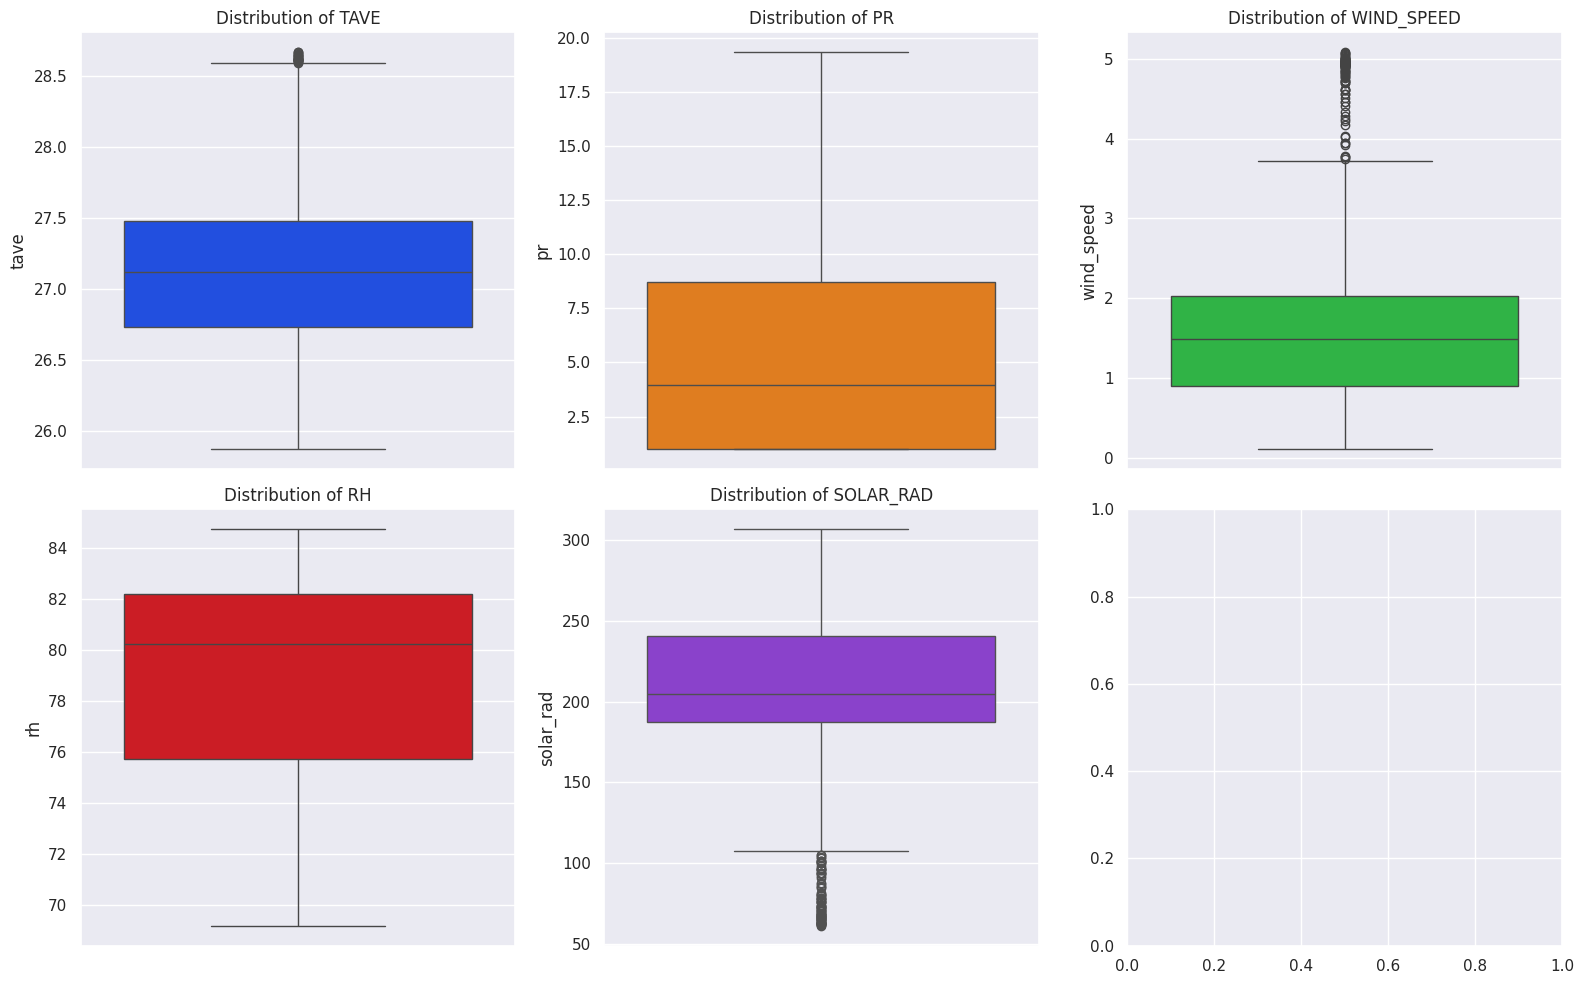

In [14]:
# @title
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

unique_colors = sns.color_palette("bright", n_colors=6)

for i, col in enumerate(synth_clim_atmo_df.columns):
    sns.boxplot(
        data=synth_clim_atmo_df, y=col, ax=axes.flatten()[i], color=unique_colors[i]
    )
    axes.flatten()[i].set_title(f"Distribution of {col.upper()}")

plt.tight_layout()
plt.show()

In [15]:
# @title
print(" === Summary Statistics of Weather Variables ===\n")
synth_clim_atmo_df.describe()

 === Summary Statistics of Weather Variables ===



,tave,pr,wind_speed,rh,solar_rad
count,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000
mean,27.172767,5.702957,1.618884,78.943483,211.467339
std,0.630820,5.743405,1.027280,3.934319,49.077276
min,25.872953,1.001873,0.107177,69.166051,61.304848
25%,26.734593,1.003500,0.896946,75.707173,187.090262
50%,27.122863,3.965755,1.482174,80.233502,204.889810
75%,27.477764,8.725171,2.031743,82.194338,240.682489
max,28.666891,19.333456,5.085098,84.732120,306.582478


### Seasonal Trends
Let us look at how these weather variables vary across months. Here, we can see if certain values are prevalent during the different seasons in the Philippines.

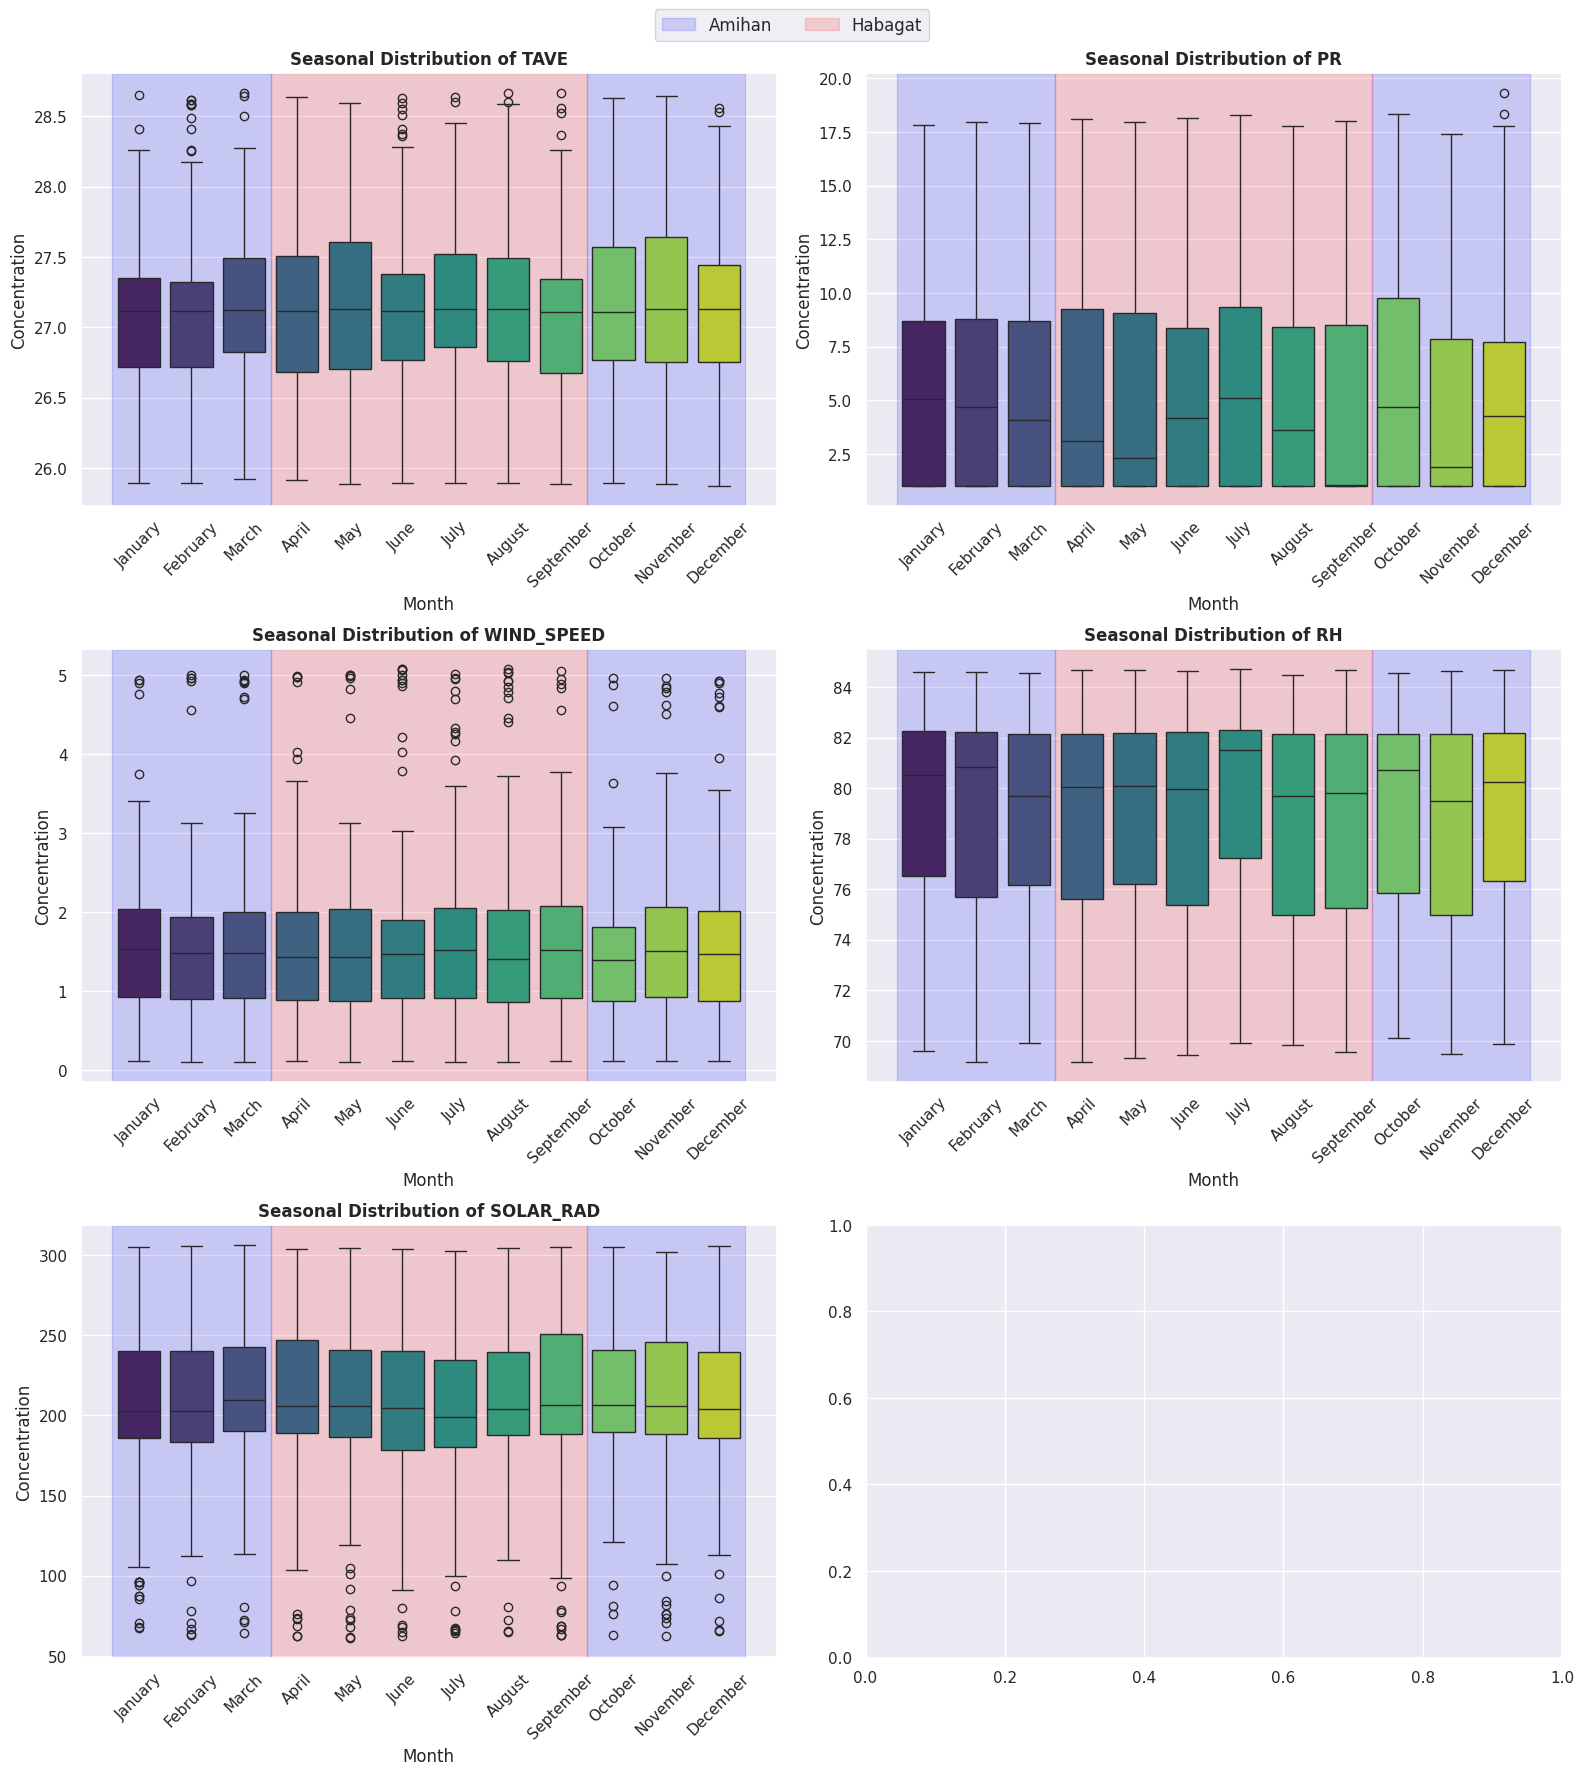

In [16]:
# @title
WEATHER_COLUMNS = ['tave', 'pr', 'wind_speed', 'rh', 'solar_rad']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

synth_clim_atmo_df['Month_Name'] = synth_clim_atmo_df.index.strftime('%B')

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, var in enumerate(WEATHER_COLUMNS):
    sns.boxplot(
        data=synth_clim_atmo_df,
        x='Month_Name',
        y=var,
        order=month_order,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(f'Seasonal Distribution of {var.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Concentration')
    axes[i].tick_params(axis='x', rotation=45)

   # --- Amihan and Habatag highlights ---
    label_a = 'Amihan' if i == 0 else "_nolegend_"
    label_h = 'Habagat' if i == 0 else "_nolegend_"

    axes[i].axvspan(-0.5, 2.5, color='blue', alpha=0.15, label=label_a)
    axes[i].axvspan(8.5, 11.5, color='blue', alpha=0.15)
    axes[i].axvspan(2.5, 8.5, color='red', alpha=0.15, label=label_h)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=2, fontsize=12)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Yearly Trends

Successfully resampled weather variables to Yearly Averages!


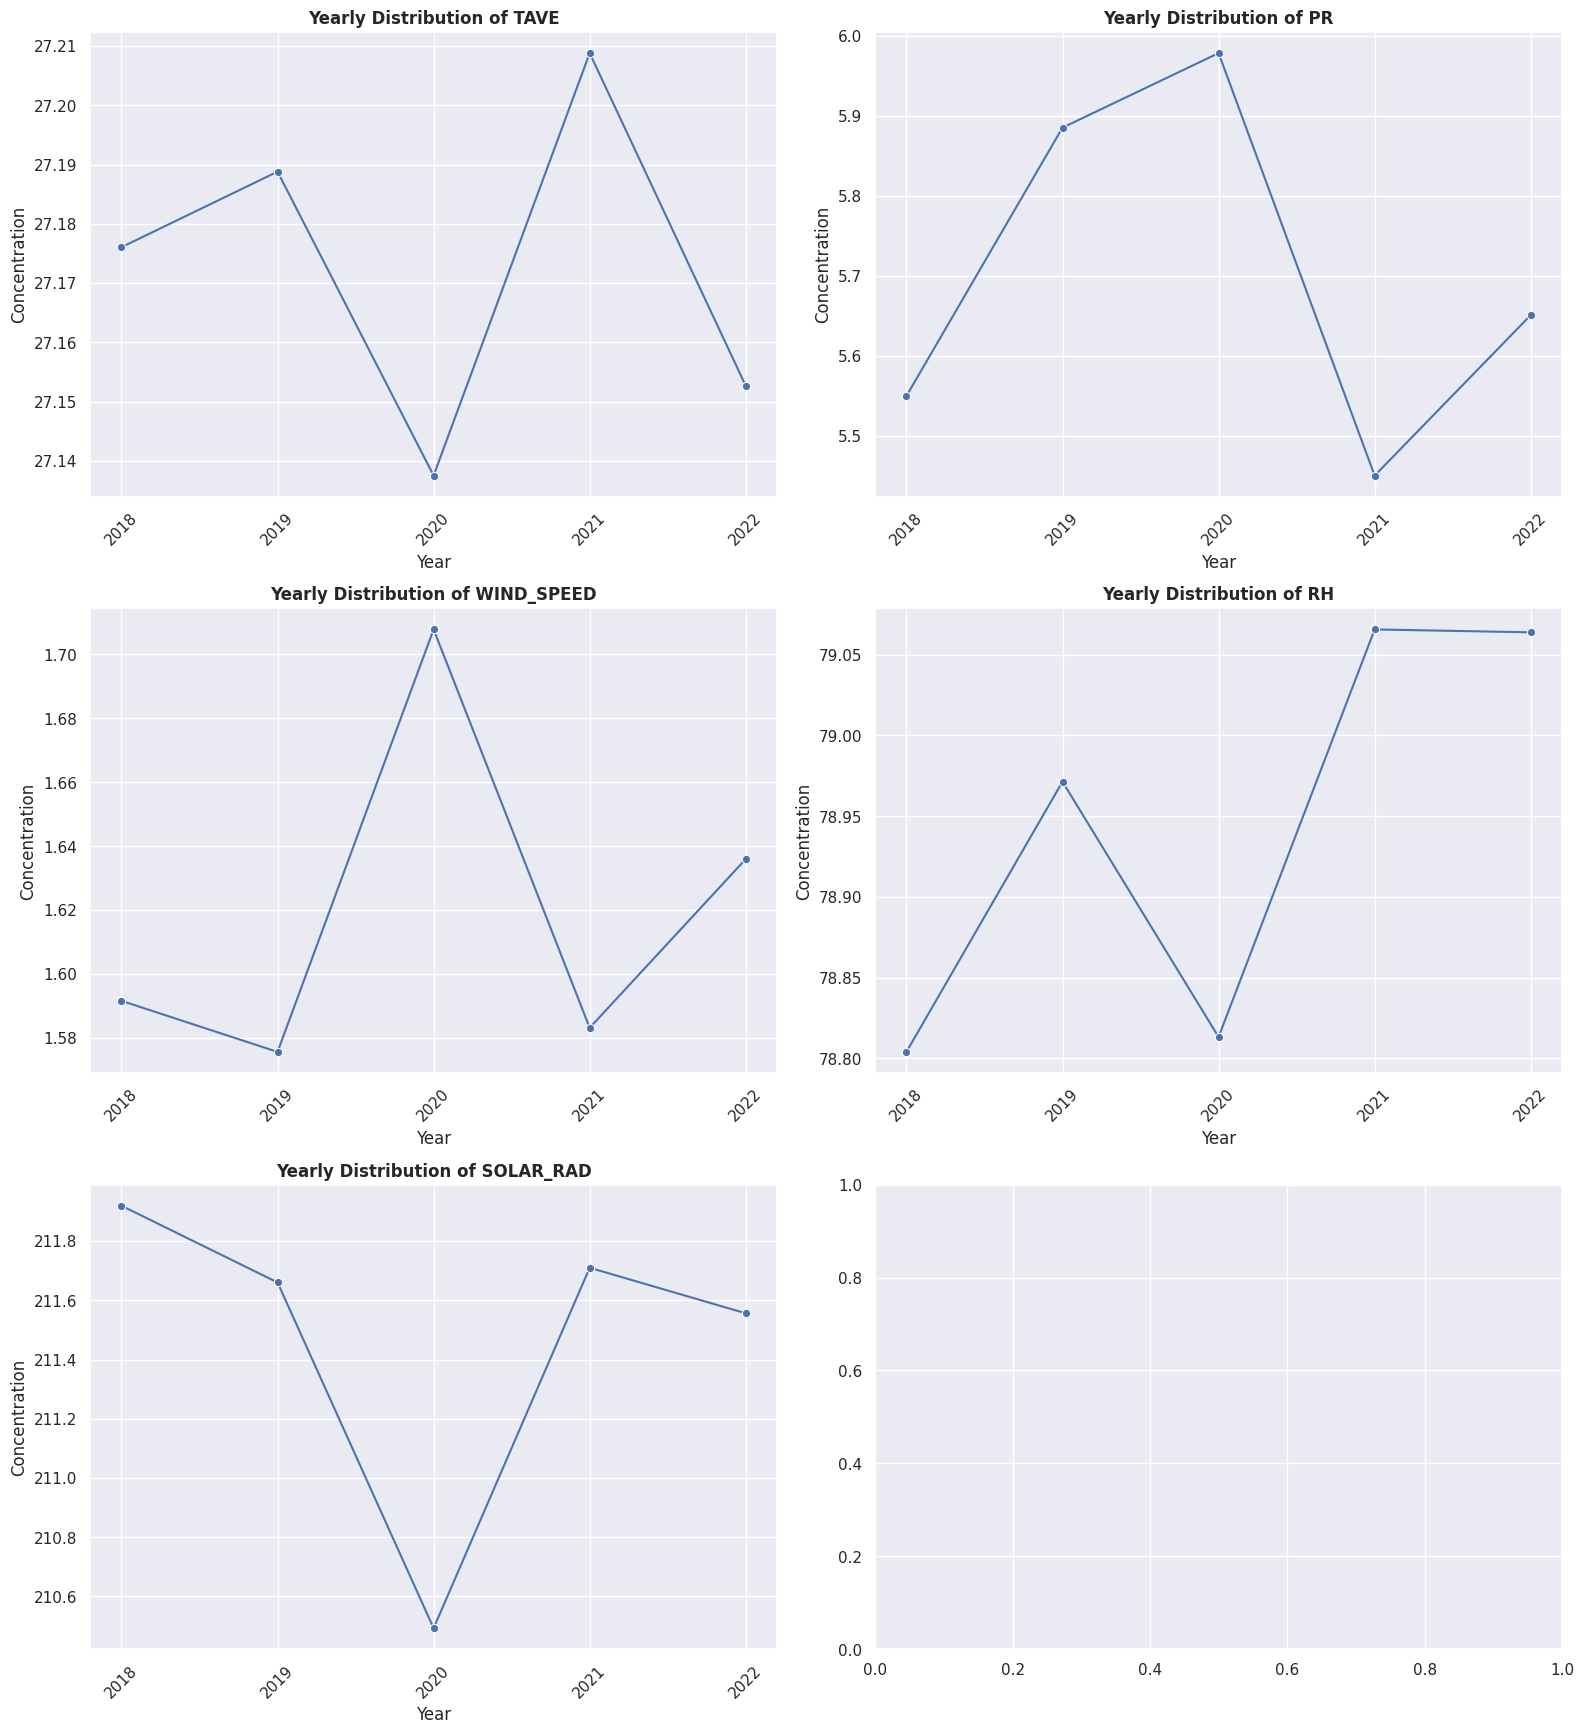

In [17]:
# @title
WEATHER_COLUMNS = ['tave', 'pr', 'wind_speed', 'rh', 'solar_rad']
yearly_atmo = synth_clim_atmo_df.iloc[:, :5].resample('Y').mean()
print("Successfully resampled weather variables to Yearly Averages!")
yearly_atmo['Year'] = yearly_atmo.index.year

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, var in enumerate(WEATHER_COLUMNS):
    sns.lineplot(data=yearly_atmo, x='Year', y=var, marker='o', ax=axes[i])

    axes[i].set_title(f'Yearly Distribution of {var.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Concentration')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticks(yearly_atmo['Year'].unique())

plt.tight_layout()
plt.subplots_adjust(top=0.95)

## Cross-Domain Correlation

This cross-domain correlation matrix shows the correlation values of the different variables available. We can see that `pm10` and `pm25` have a strong ang positive correlation while `pr` and `solar_rad` have a negative and moderate correlation.

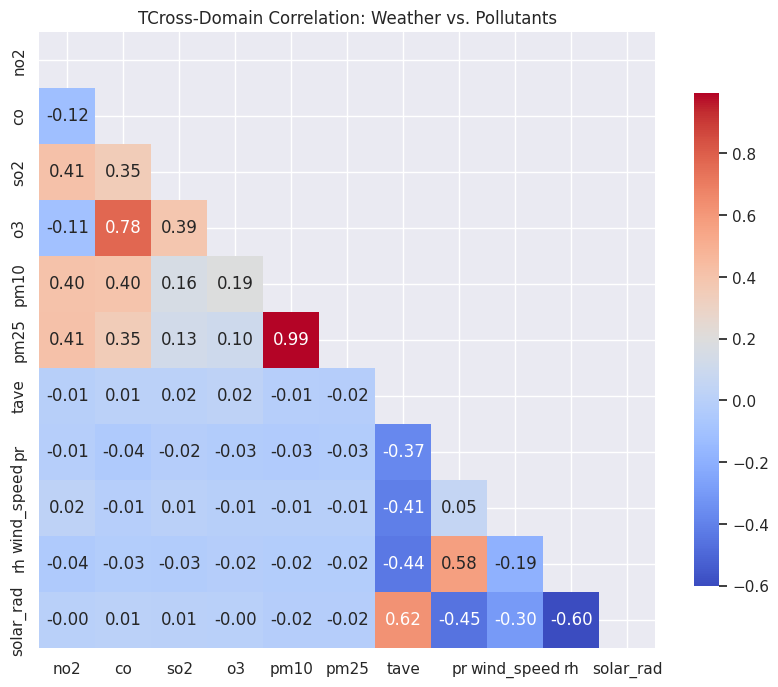

In [18]:
# @title
combined_synth_df = pd.concat([synth_clim_airqual_df.iloc[:, :6], synth_clim_atmo_df.iloc[:, :5]], axis=1)
corr_matrix = combined_synth_df.corr()

# 2. Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Set up matplotlib figure and draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            square=True,
            cbar_kws={"shrink": .8})

plt.title("TCross-Domain Correlation: Weather vs. Pollutants")
plt.show()

## Research Questions & Future Work

Having explored both the individual profiles and temporal interactions of the synthetic and real datasets for Barangay Agdao, we can establish core research questions and structural pathways for next-phase predictive modeling or generative optimization.

---

### 1. Key Research Questions
Based on the distribution profiles, seasonal variations, and cross-domain correlations observed during this EDA, future iterations of this study should aim to answer the following questions:

* **RQ1 (Generative Fidelity):** To what extent does the TimeGAN-generated synthetic data maintain the high-order temporal dynamics (such as seasonal cyclic amplitudes or daily autocorrelation) found in the real 2018 atmospheric data when expanded across multiple years (2003–2022)?
* **RQ2 (Environmental Drivers):** Which specific weather proxies (e.g., solar radiation or wind speed) demonstrate the most robust predictive power or causal impact on predicting extreme breaches of critical air quality thresholds (such as the *Acutely Unhealthy* or *Emergency* states)?
* **RQ3 (Seasonal Impact):** How significantly do seasonal weather shifts in the Philippines (Dry/Hot vs. Wet/Typhoon seasons) alter the primary chemical correlation networks among criteria pollutants (such as the relationship between $NO_2, SO_2,$ and ground-level $O_3$)?

---

### 2. Recommended Future Work

To build upon this EDA and advance the utility of the synthetic atmospheric datasets, the following developmental tasks are proposed:

* **Predictive Forecasting:** Utilize the aligned 20-year synthetic sequence to train sequence-to-sequence deep learning models (e.g., LSTMs, GRUs, or Temporal Convolutional Networks) to predict next-day particulate matter ($PM_{2.5}$ and $PM_{10}$) spikes using current weather indicators.
* **Anomalous Spillover Identification:** Establish an automated alerting framework using the custom Air Quality status breakpoints to flags days where multiple pollutants approach *Unhealthy for sensitive groups* simultaneously, providing a robust tool for localized municipal health interventions in Barangay Agdao.